<a href="https://colab.research.google.com/github/Jruiztr28/IA-y-Minirobots/blob/main/Tarea%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Guía 2: Ejercicios
1. Observe sus comportamientos en la casa, en la universidad y en el medio de transporte que utiliza.
Encuentre, para cada uno de estos escenarios sus reglas básicas.

### 1. Escenario: La Casa

* *Célula:* Cada integrante del hogar.
* *Alfabeto de estados ($w$):*
* $0$: En reposo / Dormido.
* $1$: Actividad individual concentrada (estudiando, trabajando, leyendo).
* $2$: Actividad comunal / Interacción (cenando, conversando, viendo televisión).


* *Vecindad ($U$):* Los miembros de la familia con los que se comparte una misma área física en el hogar (habitación, sala, comedor).
* *Reglas básicas de comportamiento ($f$):*
1. *Regla de sincronización del descanso:* Si la mayoría de los vecinos directos están en estado $0$ y es horario nocturno, la célula cambia a estado $0$.
2. *Regla de convocatoria comunal:* Si un vecino ingresa a un área común y cambia a estado $2$, la célula tiene una alta probabilidad de pasar de $1$ a $2$.
3. *Regla de respeto al silencio:* Si un vecino cercano está en estado $1$, la célula permanece en estado $1$ o disminuye la intensidad de sus acciones para no interferir.



---

### 2. Escenario: La Universidad (Aula de Clase o Biblioteca)

* *Célula:* Cada estudiante según su posición en los pupitres o mesas.
* *Alfabeto de estados ($w$):*
* $0$: Atento / En silencio (tomando apuntes o escuchando).
* $1$: Distraído / Murmurando con un compañero.
* $2$: Participando (haciendo preguntas o interviniendo).


* *Vecindad ($U$):* Vecindad de Moore o Von Neumann (los 4 u 8 compañeros adyacentes en el arreglo de asientos).


* *Reglas básicas de comportamiento ($f$):*
1. *Contagio de distracción:* Si 2 o más vecinos inmediatos cambian a estado $1$, la célula pasa con alta probabilidad a estado $1$.
2. *Regla de atención global:* Si los vecinos frontales y el entorno cambian a estado $0$ (por ejemplo, ante la intervención del profesor), la célula regresa automáticamente a estado $0$.
3. *Efecto de consulta:* Si un vecino pasa a estado $2$, aumenta la probabilidad de que las células circundantes pasen temporalmente a $1$ para comentar o consultar la duda.



---

### 3. Escenario: Medio de Transporte Público (Bus, Metro o Tren)

* *Célula:* Cada pasajero en el espacio físico del vehículo.
* *Alfabeto de estados ($w$):*
* $0$: En reposo (sentado/de pie, mirando el teléfono o aislado).
* $1$: En movimiento (desplazándose por el pasillo o cediendo el paso).
* $2$: En alerta de descenso (preparándose para bajar).


* *Vecindad ($U$):* Las personas a distancia de contacto o radio inmediato ($r=1$).


* *Reglas básicas de comportamiento ($f$):*
1. *Flujo y avance continuo:* Si la celda inmediata en dirección a la puerta cambia a estado $1$ (avanza), la célula pasa de $0$ a $1$ para ocupar el espacio liberado.
2. *Regla de reajuste por espacio:* Si un vecino cercano cambia a estado $2$ e intenta avanzar hacia la salida, la célula pasa temporalmente a estado $1$ para desplazarse a un costado y abrir paso.
3. *Aproximación a la estación:* Si el vehículo reduce la velocidad al llegar a una parada de interés, la célula cambia a estado $2$, activando una reacción en cadena sobre sus vecinos inmediatos.


2. Suponga una enfermedad, o un incendio forestal, o una moda, desarrolle un modelo de difusión
usando ACs probabilísticos. O simule un robot con dos ruedas que evite obstáculos.

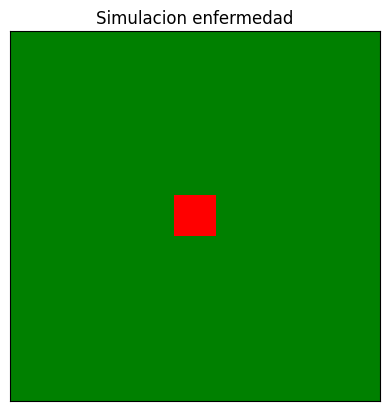

In [3]:
# Simulacion de Enfermedad con Vecindad de Moore
import random
import copy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Estados (Sano, Enfermo, Recuperado)
S, E, R = 0, 1, 2

#Matriz de 9x9 para panciente en las cords [4,4]
Filas = 9
Columnas = 9

t_sim = 30

#Probs
Prob_Recuperacion = 0.3
Prob_Contagio = 0.6

# Def funcion de Moore
def infectados(mapa, fil_centro, col_centro):
    infect_cerca = 0
    filas_t = len(mapa)
    colum_t = len(mapa[0])
    for i in range(fil_centro-1, fil_centro+2):
        for c in range(col_centro-1, col_centro+2):
            if i == fil_centro and c == col_centro: # Ignora el punto [4,4]
                continue
            if 0 <= i < filas_t and 0 <= c < colum_t:
                if mapa[i][c] == E:
                    infect_cerca += 1
    return infect_cerca



#Motor de busqueda
def reglas(act , veci_infectado):
    if act == R:
        return R
    elif act == E:
        if random.random() < Prob_Recuperacion:
            return R
        else:
            return E
    elif act == S:
        if veci_infectado > 0:
            if random.random() < Prob_Contagio:
                return E
        return S
#Sim

def crear_mapa():
    mapa = [[S for _ in range(Columnas)] for _ in range(Filas)]
    mapa[4][4] = E
    return mapa

mapa = crear_mapa()
cmap = ListedColormap(["green", "red", "purple"])

plt.ion()
fig, ax = plt.subplots()
image = ax.imshow(np.array(mapa), cmap=cmap, vmin=0, vmax=2)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Simulacion enfermedad")
plt.pause(0.3)

for generaciones in range(1, t_sim+1):
    mapa_nuevo = copy.deepcopy(mapa)

    for i in range(Filas):
        for c in range(Columnas):
            act = mapa[i][c]
            veci_infectado = infectados(mapa, i, c)
            mapa_nuevo[i][c] = reglas(act, veci_infectado)
    mapa = mapa_nuevo

    image.set_data(np.array(mapa))
    plt.pause(0.3)
plt.ioff()
plt.show()

3. Simule el comportamiento de un robot con tres sensores de distancia, que recorre un espacio
bidimensional, donde hay 4 objetos distribuidos aleatoriamente, que no se choca con esos objetos.

Semilla usada: 16
Pasos simulados: 400
¿Hubo colisión?: No
Distancia mínima alcanzada a un obstáculo: 9.7 cm (colisión si < 5.0 cm)
Obstáculos (x,y):
[[55.35334711 44.45953164]
 [59.72072307 11.73240025]
 [79.97059024 78.32396252]
 [13.54433726 74.19367703]]
Figura guardada.


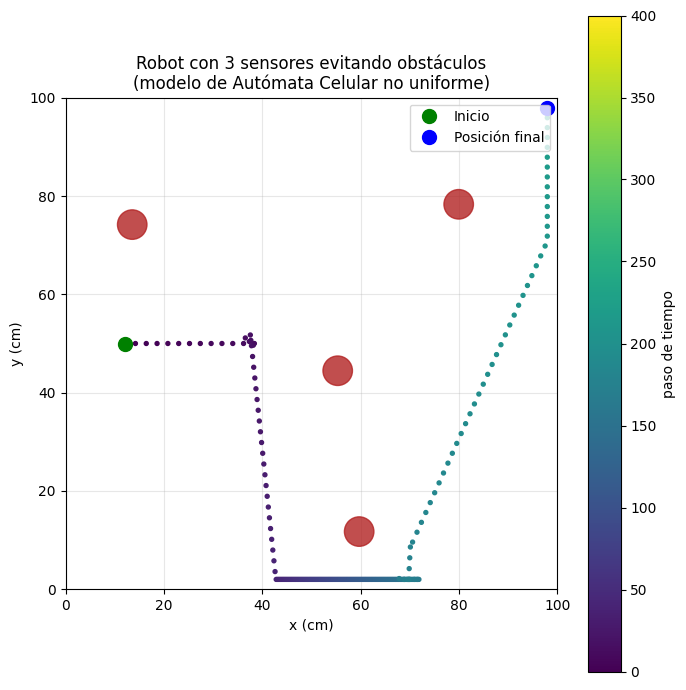

In [4]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 7
rng = np.random.default_rng(SEED)


TABLA_2_1 = {
    (0, 0, 0): (2, 2), (0, 1, 0): (0, 2), (0, 2, 0): (2, 0),
    (0, 0, 1): (2, 0), (0, 1, 1): (2, 0), (0, 2, 1): (2, 0),
    (0, 0, 2): (2, 0), (0, 1, 2): (2, 0), (0, 2, 2): (2, 0),
    (1, 0, 0): (2, 0), (1, 1, 0): (0, 2), (1, 2, 0): (0, 2),
    (1, 0, 1): (2, 0), (1, 1, 1): (1, 0), (1, 2, 1): (1, 0),
    (1, 0, 2): (2, 0), (1, 1, 2): (0, 2), (1, 2, 2): (0, 2),
    (2, 0, 0): (0, 2), (2, 1, 0): (1, 0), (2, 2, 0): (1, 0),
    (2, 0, 1): (0, 1), (2, 1, 1): (1, 0), (2, 2, 1): (1, 1),
    (2, 0, 2): (0, 1), (2, 1, 2): (1, 0), (2, 2, 2): (1, 1),
}


def estado_sensor(d, rango_max):
    """Discretiza una distancia (cm) al estado del AC {0,1,2}."""
    if d < 8:
        return 0
    elif d < 16:
        return 1
    else:
        return 2


ESPACIO = 100.0          # cm, espacio cuadrado
N_OBST = 4
RADIO_OBST = 3.0
RADIO_ROBOT = 2.0
RANGO_SENSOR = 30.0       # más allá de esto, estado = 2 (sin objeto detectado)

def generar_obstaculos(pos_inicial, n=N_OBST, min_dist_robot=20.0, min_dist_entre=15.0):
    obst = []
    intentos = 0
    while len(obst) < n and intentos < 5000:
        intentos += 1
        p = rng.uniform(10, ESPACIO - 10, size=2)
        if np.linalg.norm(p - pos_inicial) < min_dist_robot:
            continue
        if any(np.linalg.norm(p - q) < min_dist_entre for q in obst):
            continue
        obst.append(p)
    return np.array(obst)


def leer_sensor(pos, theta_sensor, obstaculos, cono_grados=45.0):
    mejor = RANGO_SENSOR
    for o in obstaculos:
        rel = o - pos
        dist = np.linalg.norm(rel) - RADIO_OBST
        if dist <= 0:
            return 0.0
        ang_obj = np.arctan2(rel[1], rel[0])
        dif = np.degrees(np.angle(np.exp(1j * (ang_obj - theta_sensor))))
        if abs(dif) <= cono_grados and dist < mejor:
            mejor = dist
    return min(mejor, RANGO_SENSOR)

def simular(pasos=400, dt=1.0, v_unit=2.2, base_ruedas=6.0):
    pos = np.array([12.0, 50.0])
    theta = np.radians(0)  # orientación inicial, apuntando hacia el centro

    obstaculos = generar_obstaculos(pos, min_dist_robot=15.0, min_dist_entre=12.0)

    trayectoria = [pos.copy()]
    estados_sensores = []
    colision = False
    paso_colision = None
    dist_min_global = np.inf

    for t in range(pasos):
        # Direcciones absolutas de los 3 sensores según orientación actual
        th_C = theta
        th_D = theta - np.pi / 2   # derecha
        th_I = theta + np.pi / 2   # izquierda

        dC = leer_sensor(pos, th_C, obstaculos)
        dD = leer_sensor(pos, th_D, obstaculos)
        dI = leer_sensor(pos, th_I, obstaculos)

        C = estado_sensor(dC, RANGO_SENSOR)
        D = estado_sensor(dD, RANGO_SENSOR)
        I = estado_sensor(dI, RANGO_SENSOR)
        estados_sensores.append((C, D, I))

        S_Mi, S_Md = TABLA_2_1[(C, D, I)]

        # Traducción de estado de motor a velocidad de rueda
        def v_rueda(s):
            return {0: 0.0, 1: v_unit, 2: -v_unit}[s]

        v_izq = v_rueda(S_Mi)
        v_der = v_rueda(S_Md)

        v_lineal = (v_izq + v_der) / 2.0
        omega = (v_der - v_izq) / base_ruedas

        theta = theta + omega * dt
        nueva_pos = pos + v_lineal * dt * np.array([np.cos(theta), np.sin(theta)])

        # Mantener el robot dentro del espacio (rebote simple en bordes)
        nueva_pos = np.clip(nueva_pos, RADIO_ROBOT, ESPACIO - RADIO_ROBOT)

        pos = nueva_pos
        trayectoria.append(pos.copy())

        # Verificación de colisión real
        for o in obstaculos:
            d = np.linalg.norm(pos - o)
            dist_min_global = min(dist_min_global, d)
            if d < (RADIO_ROBOT + RADIO_OBST):
                colision = True
                paso_colision = t
                break
        if colision:
            break

    return (np.array(trayectoria), obstaculos, estados_sensores,
            colision, paso_colision, dist_min_global)


mejor_seed = SEED
mejor_resultado = None
for s in range(1, 200):
    rng = np.random.default_rng(s)
    resultado = simular()
    _, _, _, colision, _, dist_min = resultado
    if not colision and dist_min < RADIO_ROBOT + RADIO_OBST + 6:
        mejor_seed = s
        mejor_resultado = resultado
        break

if mejor_resultado is None:
    rng = np.random.default_rng(SEED)
    mejor_resultado = simular()

(trayectoria, obstaculos, estados_sensores,
 colision, paso_colision, dist_min_global) = mejor_resultado

print(f"Semilla usada: {mejor_seed}")
print(f"Pasos simulados: {len(trayectoria)-1}")
print(f"¿Hubo colisión?: {'Sí, en el paso ' + str(paso_colision) if colision else 'No'}")
print(f"Distancia mínima alcanzada a un obstáculo: {dist_min_global:.1f} cm "
      f"(colisión si < {RADIO_ROBOT + RADIO_OBST:.1f} cm)")
print(f"Obstáculos (x,y):\n{obstaculos}")

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(0, ESPACIO)
ax.set_ylim(0, ESPACIO)
ax.set_aspect('equal')
ax.set_title("Robot con 3 sensores evitando obstáculos\n(modelo de Autómata Celular no uniforme)")
ax.set_xlabel("x (cm)")
ax.set_ylabel("y (cm)")

# Obstáculos
for o in obstaculos:
    circ = plt.Circle(o, RADIO_OBST, color='firebrick', alpha=0.8, zorder=3)
    ax.add_patch(circ)

# Trayectoria coloreada por tiempo
sc = ax.scatter(trayectoria[:, 0], trayectoria[:, 1],
                 c=np.arange(len(trayectoria)), cmap='viridis', s=8, zorder=2)
plt.colorbar(sc, ax=ax, label="paso de tiempo")

# Inicio y fin
ax.plot(*trayectoria[0], 'go', markersize=10, label='Inicio', zorder=4)
marker_fin = 'rx' if colision else 'bo'
ax.plot(*trayectoria[-1], marker_fin, markersize=10,
         label='Colisión' if colision else 'Posición final', zorder=4)

ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
print("Figura guardada.")
plt.tight_layout()
plt.show()